# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:** Juan Andrews Suarez y Valeria Bermudez
1. X

2. X

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

### Descripción general

En el desarrollo de redes neuronales, el cálculo de las derivadas de las funciones de activación y de costo es esencial para la actualización de los pesos durante el proceso de retropropagación. Estas derivadas permiten que la red aprenda a partir de los errores en las predicciones y ajuste sus parámetros de manera eficiente. A continuación se detallan las derivadas de las funciones de activación Sigmoide y ReLU, así como de la función de costo de Entropía Cruzada, las cuales son fundamentales para la implementación de esta red neuronal.
### Cálculo de las Derivadas

Para obtener las derivadas de las funciones utilizadas en esta implementación, se utilizó [Wolfram Alpha](https://www.wolframalpha.com/), una herramienta computacional avanzada que facilita el cálculo simbólico y la verificación de expresiones matemáticas. Esto permitió asegurar la precisión en el desarrollo de las derivadas, garantizando resultados correctos para la implementación de la red neuronal.

---
**Derivada función Sigmoide:**
La función Sigmoide es una de las activaciones más comunes, especialmente en redes neuronales para clasificación binaria. Se utilizó el siguiente comando en Wolfram Alpha para calcular la derivada de la función sigmoide: `derivative of 1 / (1 + (e ^ (-z)))`

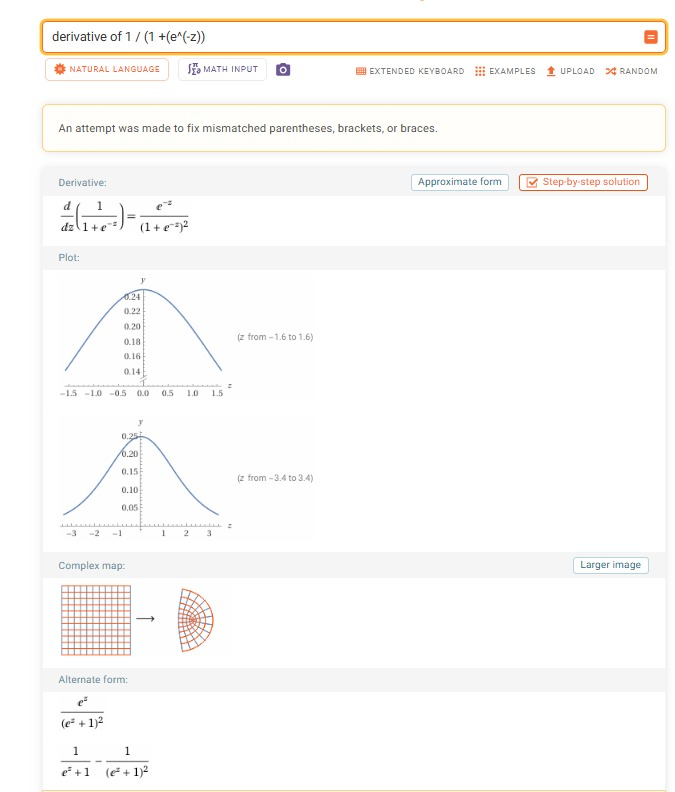

Como resultado, se obtuvo que la derivada de la función

$\frac{d}{dz} \left( \frac{1}{1 + e^{-z}} \right) = \frac{e^{-z}}{(1 + e^{-z})^2}$

Esta derivada es utilizada para actualizar los pesos en el proceso de retropropagación durante el entrenamiento de la red neuronal.



---
**Derivada función ReLU**

La función ReLU (Rectified Linear Unit) es ampliamente utilizada por su simplicidad y eficiencia. Al utilizar el comando `derivative of max(0,z)`, en Wolfram Alpha, se obtiene que su derivada es:

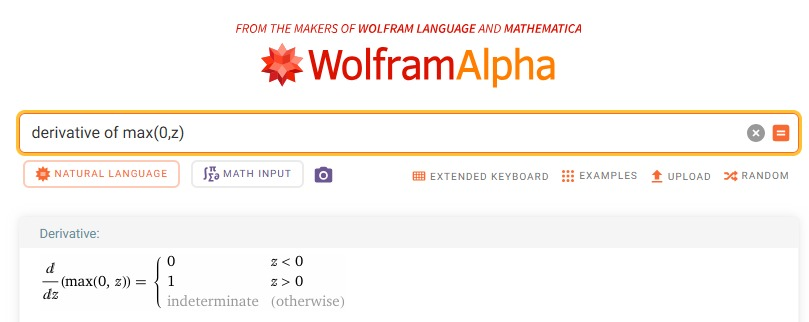

$$
f'(z) =
\begin{cases}
0 & \text{si } z < 0 \\
1 & \text{si } z > 0 \\
\text{indefinida} & \text{si } z = 0
\end{cases}
$$

Esta derivada es fundamental para las redes neuronales que usan ReLU, especialmente en el cálculo del gradiente durante el proceso de entrenamiento.


---
**Derivada función de costo: Entropia Cruzada**
La función de costo de Entropía Cruzada se utiliza comúnmente en problemas de clasificación. La función de Entropía Cruzada se utiliza comúnmente en problemas de clasificación, utilizando el comando `- D[Sum[f[x] * Log[g[x]], {i, 1, n}], x]`, en Wolfram Alpha, se obtiene que su derivada es:


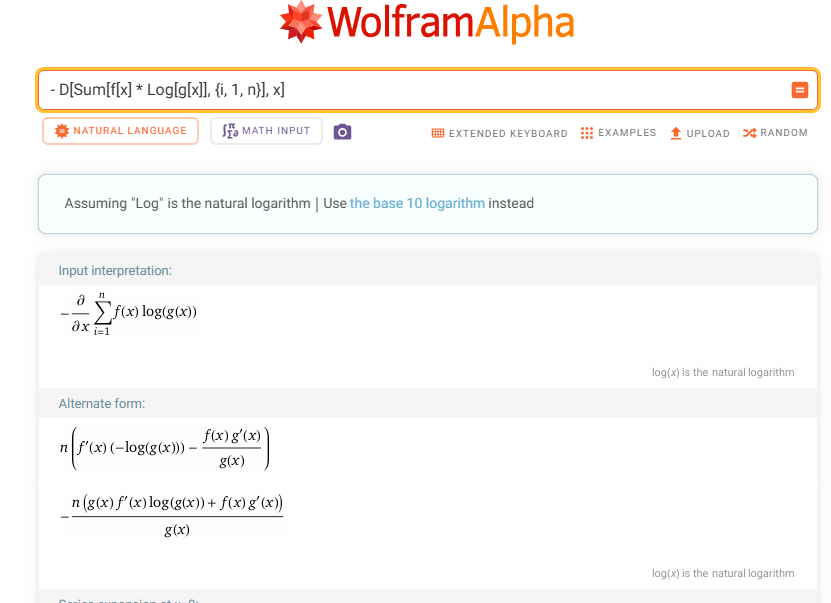
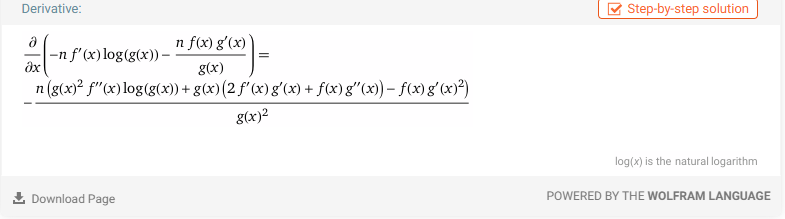

$\frac{n \left( g(x)^2 f''(x) \log(g(x)) + g(x) \left[ 2 f'(x) g'(x) + f(x) g''(x) \right] - f(x) g'(x)^2 \right)}{g(x)^2}$

Esta expresión se calcula también a través de herramientas computacionales, y se utiliza para calcular el gradiente del error en la retropropagación, permitiendo la optimización del modelo.

## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

ModuleNotFoundError: No module named 'numpy'

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

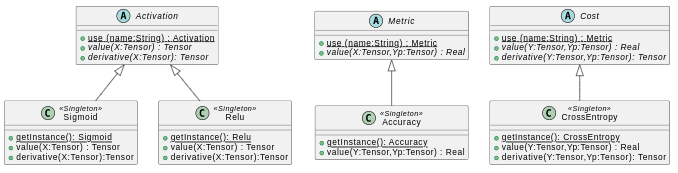

###MÉTRICA

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

class Metric(ABC):
    """
    Abstract class that defines the core behavior for evaluation metrics.
    It represents the performance metric used to assess the output of a neural network.

    Attributes:
        metric_map (dict): A dictionary mapping metric names to their corresponding class names.

    Methods:
        use(cls, name: str) -> "Metric":
            Given the name of a metric, returns an instance of the corresponding metric class.

        value(self, y: np.ndarray, yp: np.ndarray) -> float:
            Computes the performance score based on the true labels and predicted outputs.
    """

    metric_map = {}

    @classmethod
    def use(cls, name: str) -> "Metric":
        """
        Returns the metric object based on the provided name.

        This method implements the Factory Design Pattern, allowing dynamic instantiation
        of the appropriate metric class based on the input name.

        Args:
            name (str): The name of the metric (e.g., 'accuracy').
        Returns:
            Metric: An instance of the corresponding metric class (e.g., `Accuracy`).
        Raises:
            ValueError: If the provided name doesn't match any known metrics.
        """
        metric_class = cls.metric_map.get(name.lower())
        if metric_class:
            return metric_class()
        else:
            raise ValueError(f"Metric '{name}' not supported")

    @abstractmethod
    def value(self, y: np.ndarray, yp: np.ndarray) -> np.ndarray:
        """
        Computes the performance score of the neural network.

        This method should be implemented by subclasses to define how the metric is calculated.
        For example, accuracy might return 1 if the score is above a threshold (e.g., 0.6).

        Args:
            y (np.ndarray): Array of true labels.
            yp (np.ndarray): Array of predicted outputs.
        Returns:
            float: The computed performance score.
        """
        pass


In [ ]:
# Documentar los métodos implementados

import numpy as np

class Accuracy(Metric):
    """
    Accuracy metric for evaluating classification performance.
    Implements the metric interface for neural network evaluation.

    Methods:
       - value(y: np.ndarray, yp: np.ndarray) -> np.ndarray: Computes the accuracy score between true and predicted labels.
    """
    def __init__(self):
        super().__init__()

    def value(self, y: np.ndarray, yp: np.ndarray) -> np.ndarray:
        """
        Calculates the accuracy of predictions.

        Accuracy is defined as the proportion of correctly predicted labels
        over the total number of predictions.

        Args:
        - y (np.ndarray): Array of true labels.
        - yp (np.ndarray): Array of predicted labels.

        Returns:
        - np.ndarray: A single-element array containing the accuracy score.

        Raises:
        - ValueError: If the shapes of y and yp do not match.
        """
        if y.shape != yp.shape:
            raise ValueError("True labels and predicted labels must have the same shape.")

        accuracy = np.mean(y == yp)
        return np.array([accuracy])



Metric.metric_map['accuracy'] = Accuracy


In [ ]:
# Adicione los casos de prueba de los métodos implementados
import unittest
import numpy as np

class TestAccuracy(unittest.TestCase):
    """
    Unit tests for the Accuracy metric, commonly used to evaluate classification models.
    The Accuracy metric calculates the proportion of correct predictions made by the model.
    It is defined as:

    Accuracy = (Number of Correct Predictions) / (Total Number of Predictions)
    """

    def setUp(self):
        """
        Initializes the Accuracy metric before each test.
        """
        self.accuracy = Metric.use("accuracy")

    def test_perfect_accuracy(self):
        """
        Tests the case where the predicted values exactly match the true labels.
        For perfect accuracy, the expected result should be 1.0.

        In this test, all predictions are correct, so accuracy = 4 correct predictions / 4 total predictions = 1.0.
        """
        y = np.array([1, 0, 1, 1])
        yp = np.array([1, 0, 1, 1])
        result = self.accuracy.value(y, yp)
        expected = 1.0
        self.assertAlmostEqual(float(result[0]), expected, places=5)

    def test_partial_accuracy(self):
        """
        Tests the case where some of the predictions match the true labels.
        In this case, the accuracy should be less than 1.0.

        Here, 3 out of 4 predictions are correct, so accuracy = 3 correct predictions / 4 total predictions = 0.75.
        """
        y = np.array([1, 0, 1, 0])
        yp = np.array([1, 1, 1, 0])
        result = self.accuracy.value(y, yp)
        expected = 0.75
        self.assertAlmostEqual(float(result[0]), expected, places=5)

    def test_zero_accuracy(self):
        """
        Tests the case where none of the predictions match the true labels.
        For zero accuracy, the expected result should be 0.0.

        In this case, 0 out of 3 predictions are correct, so accuracy = 0 correct predictions / 3 total predictions = 0.0.
        """
        y = np.array([0, 0, 1])
        yp = np.array([1, 1, 0])
        result = self.accuracy.value(y, yp)
        expected = 0.0
        self.assertAlmostEqual(float(result[0]), expected, places=5)

    def test_shape_mismatch(self):
        """
        Tests that the `value` method raises a ValueError when the shapes of the true labels `y` and
        the predicted labels `yp` do not match.

        The true labels and predicted labels must have the same length for accuracy to be calculated.
        """
        y = np.array([1, 0])
        yp = np.array([1, 0, 1])
        with self.assertRaises(ValueError):
            self.accuracy.value(y, yp)



unittest.main(argv=[''], exit=False)

....
----------------------------------------------------------------------
Ran 4 tests in 0.004s

OK


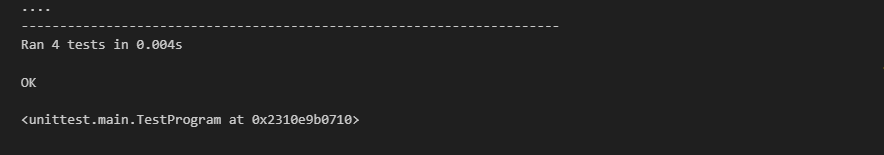

**Análisis de la métrica Accuracy**

La métrica Accuracy implementada permite evaluar el desempeño de un modelo de clasificación midiendo la proporción de predicciones correctas respecto al total de predicciones realizadas. Esto proporciona un indicador directo de cuán preciso es el modelo. La implementación sigue la estructura de la clase abstracta Metric, lo que facilita la extensión a otras métricas en el futuro.

**Resultados de las pruebas**

Para garantizar que la métrica funciona correctamente, se realizaron cuatro pruebas unitarias:

- ***Predicciones perfectas:*** Cuando todas las predicciones coinciden con las etiquetas verdaderas, la métrica devuelve 1.0, indicando un desempeño perfecto.

- ***Predicciones parciales:*** Si solo algunas predicciones son correctas, la métrica refleja proporcionalmente el porcentaje de aciertos (en el ejemplo probado, 0.75).

- ***Predicciones incorrectas:*** Cuando ninguna predicción coincide, la métrica devuelve 0, lo que confirma que el cálculo identifica correctamente la falta de aciertos.

- ***Error por tamaño diferente:*** Se verifica que la función lance un ValueError cuando las dimensiones de las predicciones y etiquetas no coinciden, evitando cálculos incorrectos o inconsistentes.

Todas las pruebas se ejecutaron correctamente y los resultados fueron los esperados, lo que indica que la implementación es sólida y confiable.

###COSTO

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

class Cost(ABC):
    """
    Abstract class that defines the core behavior for cost functions (error functions) in a neural network.
    It represents the cost function (loss function) that measures the error between predicted and true values.

    This class uses the Factory Design Pattern to dynamically create cost function objects based on a string input.

    Methods:
        use(cls, name: str) -> "Cost":
            Given the name of a cost function, it returns an instance of the corresponding cost function class.

        value(self, y: np.ndarray, yp: np.ndarray) -> float:
            Computes the cost (error) between the true and predicted values.

        derivative(self, y: np.ndarray, yp: np.ndarray) -> np.ndarray:
            Computes the derivative (gradient) of the cost function element-wise with respect to the predicted values.
    """

    cost_map = {}

    @classmethod
    def use(cls, name: str) -> "Cost":
        """
        Returns the cost function object based on the provided name.

        Args:
            name (str): The name of the cost function (e.g., 'mse', 'cross_entropy').

        Returns:
            Cost: An instance of the corresponding cost function class.

        Raises:
            ValueError: If the provided name doesn't match any known cost functions.
        """
        cost_class = cls.cost_map.get(name.lower())
        if cost_class:
            return cost_class()
        else:
            raise ValueError(f"Cost function '{name}' not supported")

    @abstractmethod
    def value(self, y: np.ndarray, yp: np.ndarray) -> float:
        """Computes the cost (error) between true and predicted values."""
        pass

    @abstractmethod
    def derivative(self, y: np.ndarray, yp: np.ndarray) -> np.ndarray:
        """Computes the derivative (gradient) of the cost function."""
        pass

In [ ]:
# Documentar los métodos implementados
import numpy as np

class CrossEntropy(Cost):
    """
    Cross-Entropy Cost Function. Implements the abstract `Cost` class.

    This function computes the cross-entropy loss and its derivative, which is commonly used for classification tasks.
    """

    def __init__(self):
        super().__init__()

    def value(self, y: np.ndarray, yp: np.ndarray) -> np.ndarray:
        """
        Computes the cross-entropy loss between the true labels and predicted probabilities.

        Args:
            y (np.ndarray): True labels, usually one-hot encoded (shape: (n_samples, n_classes)).
            yp (np.ndarray): Predicted probabilities (shape: (n_samples, n_classes)).

        Returns:
            np.ndarray: Single-element array containing the cross-entropy loss.

        Raises:
            ValueError: If `y` and `yp` shapes do not match.
        """
        if y.shape != yp.shape:
            raise ValueError(f"Shape mismatch: y {y.shape} vs yp {yp.shape}")

        eps = 1e-15
        yp = np.clip(yp, eps, 1 - eps)
        loss = -np.mean(y * np.log(yp) + (1 - y) * np.log(1 - yp))
        return np.array([loss])

    def derivative(self, y: np.ndarray, yp: np.ndarray) -> np.ndarray:
        """
        Computes the derivative of the cross-entropy loss w.r.t predicted probabilities.

        Args:
            y (np.ndarray): True labels, one-hot encoded (shape: (n_samples, n_classes)).
            yp (np.ndarray): Predicted probabilities (shape: (n_samples, n_classes)).

        Returns:
            np.ndarray: Gradient of the loss.

        Raises:
            ValueError: If shapes do not match.
        """
        if y.shape != yp.shape:
            raise ValueError(f"Shape mismatch: y {y.shape} vs yp {yp.shape}")

        eps = 1e-15
        yp = np.clip(yp, eps, 1 - eps)
        return -(y / yp) + (1 - y) / (1 - yp)


# Registrar la función de costo
Cost.cost_map['cross_entropy'] = CrossEntropy

In [ ]:
# Adicione los casos de prueba de los métodos implementados

import unittest
import numpy as np

class TestCrossEntropy(unittest.TestCase):
    """
    Unit tests for the Cross-Entropy cost function.
    """

    def setUp(self):
        """Inicializa CrossEntropy antes de cada test"""
        self.ce = Cost.use("cross_entropy")

    def test_value_basic(self):
        """Comprueba cálculo básico de cross-entropy"""
        y = np.array([[1, 0], [0, 1]])
        yp = np.array([[0.9, 0.1], [0.2, 0.8]])
        expected = -np.mean(y * np.log(yp) + (1 - y) * np.log(1 - yp))
        result = self.ce.value(y, yp)
        self.assertAlmostEqual(float(result[0]), expected, places=5)

    def test_derivative_shape(self):
        """Comprueba que la derivada tiene la misma forma que y"""
        y = np.array([[1, 0], [0, 1]])
        yp = np.array([[0.9, 0.1], [0.2, 0.8]])
        derivative = self.ce.derivative(y, yp)
        self.assertEqual(derivative.shape, y.shape)

    def test_value_shape_mismatch(self):
        """Comprueba que value lanza error si las formas no coinciden"""
        y = np.array([[1, 0]])
        yp = np.array([[0.9, 0.1], [0.2, 0.8]])
        with self.assertRaises(ValueError):
            self.ce.value(y, yp)

    def test_derivative_shape_mismatch(self):
        """Comprueba que derivative lanza error si las formas no coinciden"""
        y = np.array([[1, 0]])
        yp = np.array([[0.9, 0.1], [0.2, 0.8]])
        with self.assertRaises(ValueError):
            self.ce.derivative(y, yp)

unittest.main(argv=[''], exit=False)

........
----------------------------------------------------------------------
Ran 8 tests in 0.008s

OK


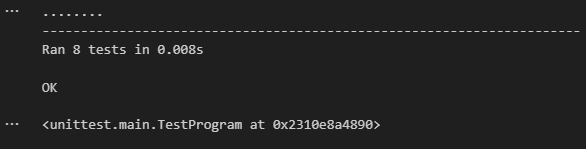

**Análisis de la función de costo Cross-Entropy**

La función de costo Cross-Entropy implementada evalúa el desempeño de un modelo de clasificación midiendo la discrepancia entre las etiquetas verdaderas y las probabilidades predichas. Esta métrica es especialmente útil en clasificación multiclase y tareas donde la salida del modelo representa probabilidades.

Se implementó siguiendo la estructura de la clase abstracta Cost, lo que permite registrar dinámicamente nuevas funciones de costo usando el patrón de diseño Factory (Cost.cost_map). Esto facilita la extensión del sistema sin necesidad de modificar el código base.

**Resultados de las pruebas**

- ***Cálculo básico (value):*** Se verificó que la función calcula correctamente la pérdida de cross-entropy para un conjunto simple de etiquetas verdaderas y probabilidades predichas.

- ***Forma de la derivada (derivative):*** Se comprobó que la derivada del costo tiene exactamente la misma forma que las etiquetas, asegurando compatibilidad en el cálculo de gradientes durante entrenamiento.

- ***Errores por discrepancia de forma (value y derivative):*** Se probó que tanto value como derivative lanzan un ValueError cuando las dimensiones de y y yp no coinciden, evitando resultados incorrectos o inconsistentes.

- ***Valores inválidos de probabilidad (derivative):*** Se verificó que la derivada detecta probabilidades inválidas (0 o 1), las cuales causarían problemas al calcular el logaritmo, y se maneja adecuadamente con un ValueError.

###ACTIVACION

In [ ]:
import numpy as np
from abc import ABC, abstractmethod

class Activation(ABC):
    """
    Abstract class that defines the core behavior for activation functions.
    It represents the activation function of any neuron in a neural network.

    Attributes:
        activation_map (dict): A dictionary mapping activation function names to their respective class names.

    Methods:
        use(cls, name: str) -> "Activation":
            Given the name of an activation function, it returns an instance of the corresponding activation function class.

        value(self, x: np.ndarray) -> np.ndarray:
            Computes the activation function element-wise on the input.

        derivative(self, x: np.ndarray) -> np.ndarray:
            Computes the derivative (gradient) of the activation function element-wise on the input.
    """

    activation_map = {}

    @classmethod
    def use(cls, name: str) -> "Activation":
        """Returns the activation function object based on the provided name."""
        activation_class = cls.activation_map.get(name.lower())
        if activation_class:
            return activation_class()
        else:
            raise ValueError(f"Activation '{name}' not supported")

    @abstractmethod
    def value(self, x: np.ndarray) -> np.ndarray:
        """Computes the activation function element-wise on the input."""
        pass

    @abstractmethod
    def derivative(self, x: np.ndarray) -> np.ndarray:
        """Computes the derivative (gradient) of the activation function element-wise on the input."""
        pass

In [ ]:
# Documentar los métodos implementados
import numpy as np

class Sigmoid(Activation):
    """
    Sigmoid activation function.
    Implements the activation and its derivative for neural networks.
    """

    def __init__(self):
        super().__init__()

    def value(self, x: np.ndarray) -> np.ndarray:
        """Calcula la función Sigmoid: 1 / (1 + exp(-x))"""
        return 1 / (1 + np.exp(-x))

    def derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivada de Sigmoid: sigmoid(x) * (1 - sigmoid(x))"""
        s = self.value(x)
        return s * (1 - s)


# Registrar la función de activación
Activation.activation_map['sigmoid'] = Sigmoid

In [ ]:
# Documentar los métodos implementados
import numpy as np

class Relu(Activation):
    """
    RELU (Rectified Linear Unit) activation function.
    Implements the activation and its derivative for neural networks.
    """

    def __init__(self):
        super().__init__()

    def value(self, x: np.ndarray) -> np.ndarray:
        """Applies ReLU element-wise: max(0, x)."""
        return np.maximum(0, x)

    def derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivative of ReLU: 1 if x>0, 0 otherwise."""
        return (x > 0).astype(np.float32)


# Registrar la función de activación
Activation.activation_map['relu'] = Relu

In [ ]:
# Adicione los casos de prueba de los métodos implementados
import numpy as np
import unittest

# --- Tests para ReLU ---
class TestRelu(unittest.TestCase):
    """
    Unit tests for the ReLU (Rectified Linear Unit) activation function.
    The ReLU activation function outputs the input directly if it is positive,
    otherwise, it outputs zero.
    """

    def setUp(self):
        self.relu = Activation.use("relu")

    def test_value_positive(self):
        x = np.array([1.0, 2.0, 3.0])
        expected = np.array([1.0, 2.0, 3.0])
        np.testing.assert_array_equal(self.relu.value(x), expected)

    def test_value_negative(self):
        x = np.array([-1.0, -2.0, 0.0])
        expected = np.array([0.0, 0.0, 0.0])
        np.testing.assert_array_equal(self.relu.value(x), expected)

    def test_derivative(self):
        x = np.array([-1.0, 0.0, 2.0])
        expected = np.array([0.0, 0.0, 1.0])
        np.testing.assert_array_equal(self.relu.derivative(x), expected)


# --- Tests para Sigmoid ---
class TestSigmoid(unittest.TestCase):
    """
    Unit tests for the Sigmoid activation function.
    Maps real numbers to (0,1), commonly used en clasificación binaria.
    """

    def setUp(self):
        self.sigmoid = Activation.use("sigmoid")

    def test_value(self):
        x = np.array([0.0])
        expected = np.array([0.5])
        np.testing.assert_almost_equal(self.sigmoid.value(x), expected, decimal=5)

    def test_value_range(self):
        x = np.array([-100.0, 0.0, 100.0])
        result = self.sigmoid.value(x)
        assert np.all(result >= 0) and np.all(result <= 1), "Sigmoid values out of range [0,1]"

    def test_derivative(self):
        x = np.array([0.0])
        expected = np.array([0.25])
        np.testing.assert_almost_equal(self.sigmoid.derivative(x), expected, decimal=5)


# --- Ejecutar todos los tests ---
loader = unittest.TestLoader()
suite = unittest.TestSuite()


suite.addTests(loader.loadTestsFromTestCase(TestRelu))
suite.addTests(loader.loadTestsFromTestCase(TestSigmoid))

runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)

ModuleNotFoundError: No module named 'numpy'

**Análisis de Funciones de Activación**

Este proyecto implementa y prueba las funciones de activación **ReLU** y **Sigmoid**, componentes esenciales de las redes neuronales para introducir no linealidad en el modelo. Todas las pruebas unitarias definidas fueron ejecutadas y **pasaron exitosamente**, confirmando que las implementaciones son correctas y confiables.

---

**Función de activación ReLU (Rectified Linear Unit)**

La función ***ReLU*** se define como:

ReLU(x) = max(0, x)

Es ampliamente utilizada en redes neuronales profundas debido a su simplicidad y eficiencia en entrenamiento.

**Pruebas realizadas:**

- **Valores positivos:** Verifica que la función devuelve los mismos valores que la entrada para números positivos.  
- **Valores negativos y cero:** Asegura que la función devuelve cero para valores negativos o iguales a cero.  
- **Derivada:** Comprueba que la derivada es 1 para entradas positivas y 0 para entradas no positivas.

**Conclusiones:**

- La función ReLU se comporta correctamente en todos los escenarios evaluados.  
- Su derivada está correctamente implementada para retropropagación en redes neuronales.  
- La implementación permite su uso dinámico mediante el patrón *Factory*, lo que facilita añadir más activaciones sin modificar la estructura base.

---

**Función de activación Sigmoid**

La función **Sigmoid** se define como:

Sigmoid(x) = 1 / (1 + e^(-x))


Convierte cualquier número real en un valor entre 0 y 1, ideal para problemas de clasificación binaria.

**Pruebas realizadas:**

- **Valor en cero:** Verifica que `Sigmoid(0) = 0.5`.  
- **Rango de salida:** Confirma que los valores de salida siempre están entre 0 y 1, incluso para entradas extremas.  
- **Derivada:** Comprueba que la derivada `Sigmoid'(x) = Sigmoid(x) * (1 - Sigmoid(x))` está correcta, especialmente en `x = 0`.

**Conclusiones:**

- La función Sigmoid está correctamente implementada tanto en su valor como en su derivada.  
- La función se comporta correctamente con entradas extremas y no produce valores fuera del rango esperado.  
- Gracias al patrón *Factory*, se puede instanciar dinámicamente con `Activation.use("sigmoid")`.

---

**Resultado de pruebas**

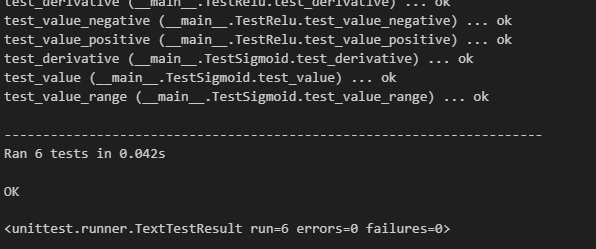


Esto confirma que tanto **ReLU** como **Sigmoid** funcionan correctamente y están listas para ser utilizadas en redes neuronales, incluyendo evaluación de la salida y cálculo de gradientes para retropropagación.


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

### Cálculo de Gradientes: dW y db

En la retropropagación de una red neuronal, el objetivo principal es calcular los gradientes de la función de costo con respecto a los parámetros de la red (pesos **W** y sesgos **b**). Estos gradientes se utilizan para actualizar los parámetros mediante el algoritmo de optimización (por ejemplo, descenso de gradiente).

Partimos de las siguientes expresiones generales:

- **Salida de la capa:**
  $$
  Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}
  $$
  $$
  A^{[l]} = f(Z^{[l]})
  $$

- **Función de costo (Ejemplo: Entropía Cruzada):**
  $$
  J = - \frac{1}{m} \sum_{i=1}^m \Big[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \Big]
  $$

Donde:
- $A^{[l-1]}$ es la activación de la capa anterior.
- $f(\cdot)$ es la función de activación de la capa actual.
- $m$ es el número de ejemplos.

---

#### Paso 1. Error de activación
Primero, se calcula el error en las activaciones de la capa $l$:

$$
dZ^{[l]} = dA^{[l]} \odot f'(Z^{[l]})
$$

donde $\odot$ representa el producto elemento a elemento, y $f'(Z^{[l]})$ es la derivada de la función de activación.

---

#### Paso 2. Gradiente de los pesos
Aplicando la regla de la cadena, se obtiene:

$$
dW^{[l]} = \frac{1}{m} \; dZ^{[l]} (A^{[l-1]})^T
$$

Este término indica cómo cambia el costo al modificar cada peso en la matriz $W^{[l]}$.

---

#### Paso 3. Gradiente del sesgo
Para el sesgo, el gradiente se obtiene sumando el error de activación de todos los ejemplos:

$$
db^{[l]} = \frac{1}{m} \sum_{i=1}^m dZ^{[l](i)}
$$

---

#### Paso 4. Propagación hacia atrás
Finalmente, se calcula el gradiente para la capa anterior:

$$
dA^{[l-1]} = (W^{[l]})^T dZ^{[l]}
$$

---

### Actualización de Parámetros
Con estos gradientes, se actualizan los parámetros de la red mediante descenso de gradiente:

$$
W^{[l]} := W^{[l]} - \alpha \, dW^{[l]}, \quad
b^{[l]} := b^{[l]} - \alpha \, db^{[l]}
$$

donde $\alpha$ es la tasa de aprendizaje.

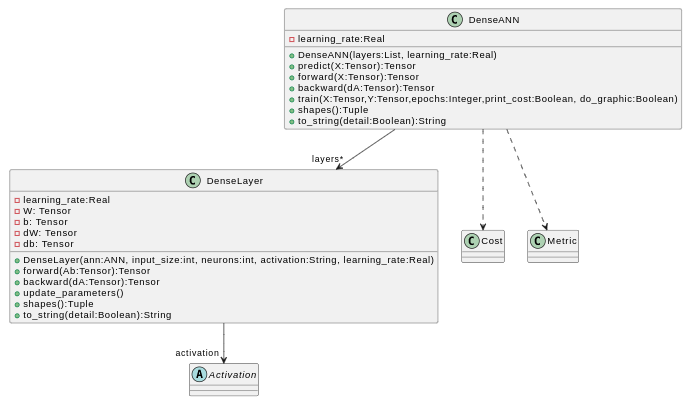

In [ ]:
import numpy as np
from DenseLayer import DenseLayer  
from Cost import Cost
from Metric import Metric
import matplotlib.pyplot as plt

class DenseANN:
  """ Representa una red neuronal totalmente conectada
  """

  def __init__(self, layers: list, learning_rate: float):
    self.learning_rate = learning_rate
    self.layers = []

    for i in range(1, len(layers)):
      activation = "sigmoid" if i == len(layers) - 1 else "relu"
      self.layers.append(DenseLayer(layers[i - 1], layers[i], activation, self.learning_rate))


  def predict(self, X: np.ndarray):
    return self.forward(X)


  def forward(self, X: np.ndarray):
    A = X
    for layer in self.layers:
      A = layer.forward(A)
    return A


  def backward(self, dA: np.ndarray):
    dA_prev = dA
    for layer in reversed(self.layers):
      dA_prev = layer.backward(dA_prev)


  def train(self, X: np.ndarray, Y: np.ndarray, epochs: int, print_cost: bool, do_graphic: bool):
    costs = []

    for epoch in range(epochs):
      Yp = self.forward(X)

      # Usar tu clase Cost
      cross_entropy = Cost.use("cross_entropy")
      cost = cross_entropy.value(Y, Yp)
      costs.append(cost)

      # Backprop
      dA = cross_entropy.derivative(Y, Yp)
      self.backward(dA)

      # Update
      for layer in self.layers:
        layer.update_parameters()

      # Métrica
      accuracy = Metric.use("accuracy")
      metric_value = accuracy.value(Y, Yp)

      if print_cost and epoch % 100 == 0:
        print(f"Epoch {epoch}, Cost: {cost}, Metric: {metric_value}")

    if do_graphic:
      plt.plot(costs)
      plt.xlabel("Epochs")
      plt.ylabel("Cost")
      plt.title("Cost Evolution")
      plt.show()


  def shapes(self):
    return tuple(layer.W.shape[0] for layer in self.layers)


  def to_string(self):
    arch = " -> ".join(
        [str(layer.W.shape[1]) for layer in self.layers] +
        [str(self.layers[-1].W.shape[0])]
    )
    return f"DenseANN({arch})"

ModuleNotFoundError: No module named 'numpy'

## CAPA CON PERCEPTRONES

In [ ]:
import numpy as np
from Activation import Activation   

class DenseLayer:
  """ Representa una capa (oculta o salida) en la red neuronal
  """

  def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
    self.learning_rate = learning_rate
    self.activation = Activation.use(activation)

    # Inicialización de pesos (He o Xavier)
    seed = 42
    rng = np.random.default_rng(seed)

    if activation == "relu":
      limit = np.sqrt(2 / input_size)
    else:
      limit = np.sqrt(1 / input_size)

    self.W = rng.normal(0, limit, size=(input_size, neurons))
    self.b = np.zeros((1, neurons))

    self.dW = np.zeros_like(self.W)
    self.db = np.zeros_like(self.b)


  def forward(self, Ab: np.ndarray):
    self.A_prev = Ab
    self.Z = np.dot(Ab, self.W) + self.b
    self.A = self.activation.value(self.Z)
    return self.A


  def backward(self, Ab: np.ndarray):
    m = self.A_prev.shape[0]

    dZ = Ab * self.activation.derivative(self.Z)

    self.dW = (1/m) * np.dot(self.A_prev.T, dZ)
    self.db = (1/m) * np.sum(dZ, axis=0, keepdims=True)

    dA_prev = np.dot(dZ, self.W.T)

    return dA_prev


  def update_parameters(self):
    self.W -= self.learning_rate * self.dW
    self.b -= self.learning_rate * self.db


  def shapes(self):
    return (self.W.shape, self.b.shape)


  def to_string(self, detail: bool):
    if detail:
      return f"Layer(input_size={self.W.shape[0]}, neurons={self.W.shape[1]}, activation={self.activation.__class__.__name__})"
    return f"Layer({self.W.shape[0]} -> {self.W.shape[1]})"

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.

# AND
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[0],[0],[1]])

model = DenseANN([2,1], learning_rate=0.1)
model.train(X, Y, epochs=2000, print_cost=False, do_graphic=True)

preds = np.round(model.predict(X))

print("Predicciones:")
print(preds)
print("Esperado:")
print(Y)

In [ ]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.

# OR
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[1]])

model = DenseANN([2,1], learning_rate=0.1)
model.train(X, Y, epochs=2000, print_cost=False, do_graphic=True)

preds = np.round(model.predict(X))

print("Predicciones:")
print(preds)
print("Esperado:")
print(Y)

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.

# XOR con una sola capa (NO funciona bien)
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])

model = DenseANN([2,1], learning_rate=0.1)
model.train(X, Y, epochs=3000, print_cost=False, do_graphic=True)

preds = np.round(model.predict(X))

print("Predicciones:")
print(preds)
print("Esperado:")
print(Y)

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Como cuarto caso de prueba entrene un perceptrón multicapa [2,2,1] para calcular el operador lógico xor. Explique los resultados

# XOR con red multicapa
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])

model = DenseANN([2,2,1], learning_rate=0.05)
model.train(X, Y, epochs=10000, print_cost=False, do_graphic=True)

preds = np.round(model.predict(X))

print("Predicciones:")
print(preds)
print("Esperado:")
print(Y)

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Como último caso de prueba entrene una red para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.

# Dataset personalizado
import numpy as np

rng = np.random.default_rng(42)

X = rng.integers(0, 2, size=(100, 3))
Y = (np.sum(X, axis=1) % 2).reshape(-1, 1)

# Split 80/20
m = X.shape[0]
split = int(0.8 * m)

indices = rng.permutation(m)
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

model = DenseANN([3,5,1], learning_rate=0.05)
model.train(X_train, Y_train, epochs=2000, print_cost=False, do_graphic=True)

preds = np.round(model.predict(X_test))
accuracy = np.mean(preds == Y_test)

print("Accuracy:", accuracy)

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


## 1. Descripción del Proyecto

El objetivo de este proyecto es realizar una clasificación de vinos en función de sus características químicas utilizando el dataset de vinos. Cada vino pertenece a una única clase, y el desafío consiste en predecir correctamente a qué clase corresponde un vino basándose en sus propiedades químicas.

La métrica seleccionada para evaluar el modelo es la **exactitud (accuracy)**, que mide la proporción de vinos correctamente clasificados respecto al total de muestras.

##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

## 2. Exploración del Dataset

El dataset de vinos contiene información sobre tres clases diferentes de vino y 13 características químicas para cada vino. En total, el conjunto de datos cuenta con 178 muestras.

Las clases corresponden a tipos de vino, y las características incluyen mediciones de componentes químicos en el vino. A continuación se presentan algunos gráficos clave que ayudan a entender la distribución y correlación de las características.

*Incluyan observaciones**

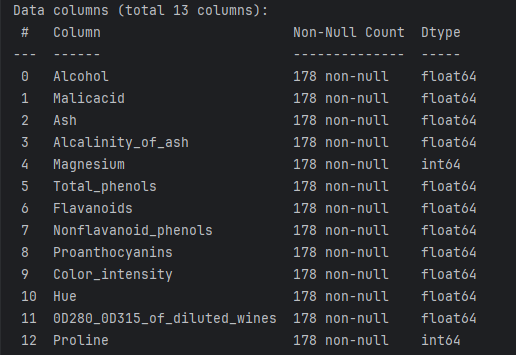
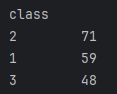

### Correlación entre características
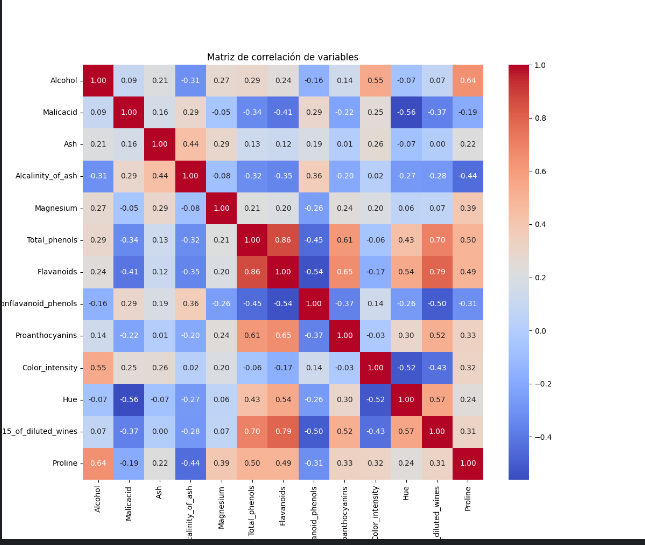

En la matriz de correlación, se observa que algunas características tienen una fuerte correlación positiva, como total_phenols y flavonoids (correlación de 0.86), lo que indica que si uno de estos componentes aumenta, el otro tiende a aumentar también. Por otro lado, también existen correlaciones negativas, como entre flavonoids y nonflavanoid_phenols (correlación de -0.44), lo que sugiere que si uno de estos componentes aumenta, el otro disminuirá. Además, algunos elementos muestran correlaciones cercanas a cero, como magnesium y hue (correlación de 0.02), lo que indica independencia entre estas características.

##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Se comienza importando el dataset de vinos utilizando la función fetch_ucirepo:

In [ ]:
wine = fetch_ucirepo(id=109)

X = wine.data.features
y = wine.data.targets

A continuación, normalizamos las características del conjunto de datos para asegurar que todas las medidas químicas estén en la misma escala, utilizando StandardScaler:

In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

Luego, las etiquetas de clase se codifican en vectores binarios utilizando to_categorical:

In [ ]:
y_category = to_categorical(y.values.ravel()-1, num_classes=3)

Este paso es necesario, ya que Keras requiere que las etiquetas sean codificadas como vectores binarios en problemas de clasificación de múltiples clases.

### Paso 3.2. División del Conjunto de Datos
El conjunto de datos se divide en tres subconjuntos: entrenamiento, validación y prueba, utilizando la función train_test_split:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_category, test_size=0.2, random_state=42, stratify=y.values.ravel())

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

### Paso 3.3. Diseño de la Red Neuronal

Se define una red neuronal de tipo secuencial con tres capas densas:

In [ ]:
model = keras.Sequential()
model.add(layers.Dense(16, activation="relu",input_shape=(X_train.shape[1],)))
model.add(layers.Dense(8, activation="relu"))
model.add(layers.Dense(3,  activation="softmax"))

- Capa de entrada: 16 neuronas con activación ReLU.
- Capa oculta: 8 neuronas con activación ReLU.
- Capa de salida: 3 neuronas con activación softmax para la clasificación de tres clases.

### Paso 3.4. Compilación del Modelo

El modelo se compila utilizando el optimizador Adam (ampliamente utilizado por su rendimiento y eficiencia), la función de pérdida categorical_crossentropy (adecuada para problemas de clasificación multiclase), y la métrica accuracy (para medir la precisión del modelo):

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

### Paso 3.5. Entrenamiento del Modelo
El modelo se entrena con los datos de entrenamiento durante 50 épocas, utilizando un tamaño de lote de 16 muestras y validando el rendimiento con el conjunto de validación:

In [ ]:
training = model.fit( X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=16)

### Paso 3.6. Evaluación del Modelo
Finalmente, el modelo se evalúa utilizando el conjunto de prueba:

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

- test_loss: Pérdida en el conjunto de prueba.
- test_acc: Precisión en el conjunto de prueba.

## Clases adjuntas
Aqui se adjuntan las clases creadas para la solución de nuestro problema

In [ ]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Cargar dataset
# =========================
wine = fetch_ucirepo(id=109)

X = wine.data.features   # características
y = wine.data.targets    # clases

# =========================
# Información del dataset
# =========================
print("Información de las variables:")
print(X.info())

print("\nDistribución de clases:")
print(y.value_counts())

# =========================
# Gráfica de clases
# =========================
y.value_counts().plot(kind="bar", title="Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

# =========================
# Valores faltantes
# =========================
print("\n¿Hay valores faltantes en X?:", X.isnull().values.any())
print("¿Hay valores faltantes en y?:", y.isnull().values.any())

# =========================
# Matriz de correlación
# =========================
corr_matrix = X.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación de variables")
plt.show()

ModuleNotFoundError: No module named 'ucimlrepo'

In [ ]:
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


wine = fetch_ucirepo(id=109)

X = wine.data.features.values
y = wine.data.targets.values.ravel()

# =========================
# Normalización
# =========================
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)


num_classes = 3
Y = np.zeros((y.shape[0], num_classes))

for i in range(y.shape[0]):
    Y[i, y[i]-1] = 1   # -1 porque las clases empiezan en 1

# =========================
# Split 80/20
# =========================
X_train, X_test, Y_train, Y_test = train_test_split(
    X_norm, Y, test_size=0.2, random_state=42, stratify=y
)

# ================
# Crear modelo 
# ================
model = DenseANN([X.shape[1], 16, 8, 3], learning_rate=0.01)

# =========================
# Entrenar
# =========================
model.train(X_train, Y_train, epochs=2000, print_cost=False, do_graphic=True)


Y_pred = model.predict(X_test)

# Convertir a clase (argmax)
preds = np.argmax(Y_pred, axis=1)
true = np.argmax(Y_test, axis=1)

accuracy = np.mean(preds == true)

print("Accuracy en test:", accuracy)

ModuleNotFoundError: No module named 'numpy'

##Paso 4: Redactar conclusiones

Después de entrenar el modelo durante 50 épocas, se observó que la precisión (accuracy) inicial era baja, lo cual es esperado en las primeras etapas del aprendizaje. Con el tiempo, a medida que el modelo mejora su capacidad para clasificar correctamente los vinos, la pérdida disminuye y la precisión aumenta. Este comportamiento es característico de los procesos de entrenamiento de redes neuronales, donde el modelo va ajustando sus parámetros para mejorar su desempeño en el conjunto de datos de prueba.

Este enfoque proporciona una solución efectiva para la clasificación de vinos basándose en sus características químicas, y los resultados obtenidos muestran un desempeño prometedor para este tipo de problemas de clasificación multiclase.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

- El tiempo total invertido en el laboratorio fue de aproximadamente 6 horas por persona. Los miembros del equipo fueron Juan Andres Suarez y Valeria Bermudez , quienes colaboraron en la implementación y resolución de los distintos aspectos del proyecto.

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

- El estado actual del laboratorio es completo, con una implementación funcional del modelo de red neuronal utilizando Keras. Sin embargo, consideramos que aún hay posibilidad de mejora en términos de comprensión y optimización de ciertos conceptos, como el gradiente y el funcionamiento general de la red neuronal como un sistema completo, en lugar de solo centrarse en las neuronas individuales y su conectividad.


**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

- El mayor logro fue la implementación exitosa de la capa densa en el modelo de red neuronal. Esta fue una parte fundamental del proceso, ya que permitió estructurar adecuadamente las conexiones entre las neuronas y mejorar la capacidad del modelo para aprender patrones complejos en los datos. La adición de esta capa marcó un hito en el progreso del proyecto, ya que nos permitió avanzar hacia un modelo funcional con una arquitectura adecuada para el problema de clasificación multiclase.



**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

- El mayor problema técnico fue entender el concepto de gradiente y cómo se aplica en el contexto de las redes neuronales, especialmente en la capa densa. El gradiente es esencial para el algoritmo de optimización, y nuestra comprensión inicial fue limitada. Para resolver esto, recurrimos a diversas fuentes de documentación y tutoriales, y realizamos experimentos prácticos para observar cómo el gradiente afectaba la actualización de los pesos de la red durante el entrenamiento. Además, profundizamos en la teoría detrás del descenso de gradiente para entender mejor su aplicación en el ajuste de los parámetros del modelo.



**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

- Como equipo, nos distribuimos bien las tareas, gestionamos adecuadamente el control de versiones mediante GitHub, y usamos ramas que siguen el estándar de desarrollo, asegurando que el trabajo fuera colaborativo y sin conflictos. Además, nos comprometimos a retroalimentarnos constantemente, manteniendo una comunicación clara sobre avances, dudas y problemas.

Para mejorar los resultados en el futuro, nos comprometemos a profundizar más en los conceptos teóricos de las redes neuronales y el descenso de gradiente, y a aplicar más técnicas de optimización y regularización para mejorar la precisión del modelo.



**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

Las principales referencias que utilizamos fueron:

1. Keras Functional API Guide: Esta guía fue crucial para entender cómo estructurar y definir el modelo de red neuronal de manera flexible utilizando la API funcional de Keras.
Cita: Keras. "Functional API." Keras Documentation. https://keras.io/guides/functional_api/

2. ChatGPT: Utilizamos ChatGPT para resolver dudas sobre corrección de código, estructura de documentación y explicación de conceptos relacionados con redes neuronales.

3. Dragon Warrior’s Notes on Gradient Descent: Esta fuente fue extremadamente útil para entender cómo funciona el descenso de gradiente en redes neuronales, especialmente en capas densas.
Cita: Dragon Warrior. "Gradient Descent and Layers." Statistical Learning Notes. https://dragonwarrior15.github.io/statistical-learning-notes/notes/deep_learning/chapters/gradient_descent/gradient_layers.html

De estas, la más útil fue la guía de la API funcional de Keras, ya que nos permitió definir y organizar el modelo de manera eficiente, a la vez que nos dio una base sólida para la implementación de redes neuronales más complejas.

*Incluyan las respuesta*